In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df=pd.read_csv("AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [4]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
df.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [6]:
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [8]:
#Month is object
df['Month']=pd.to_datetime(df['Month'])


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [10]:
df.set_index('Month',inplace=True)

In [11]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [21]:
df=df.rename(columns={"#Passengers":"Passengers"})

Text(0.5, 1.0, 'Monthly Air passengers')

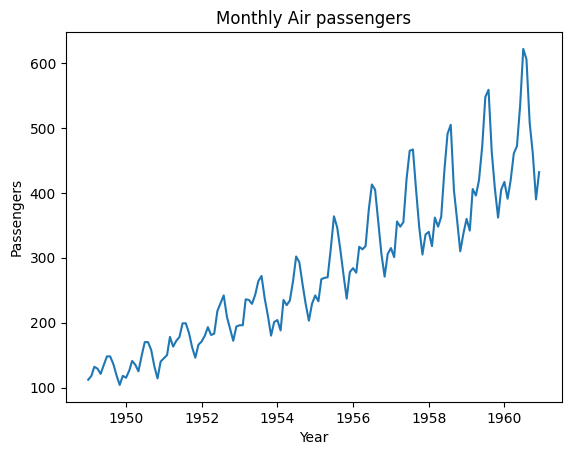

In [22]:
plt.plot(df)
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.title('Monthly Air passengers')

In [15]:
#Decompostion ->Trend,Seasonality,Noise
from statsmodels.tsa.seasonal import  seasonal_decompose

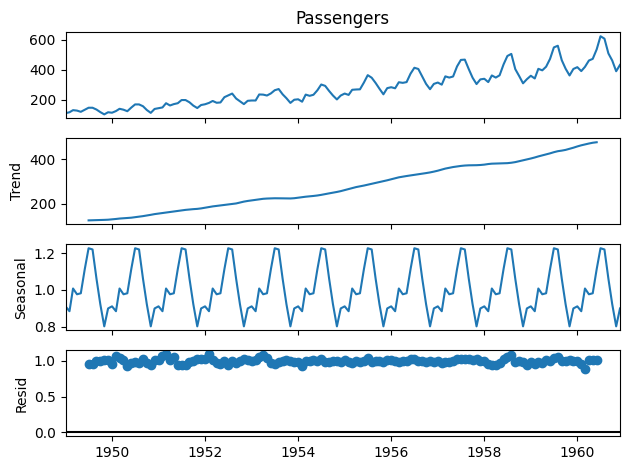

In [23]:
decomposition=seasonal_decompose(df['Passengers'],model='multiplicative',period=12)
decomposition.plot()
plt.show()


In [24]:
df_log=np.log(df)

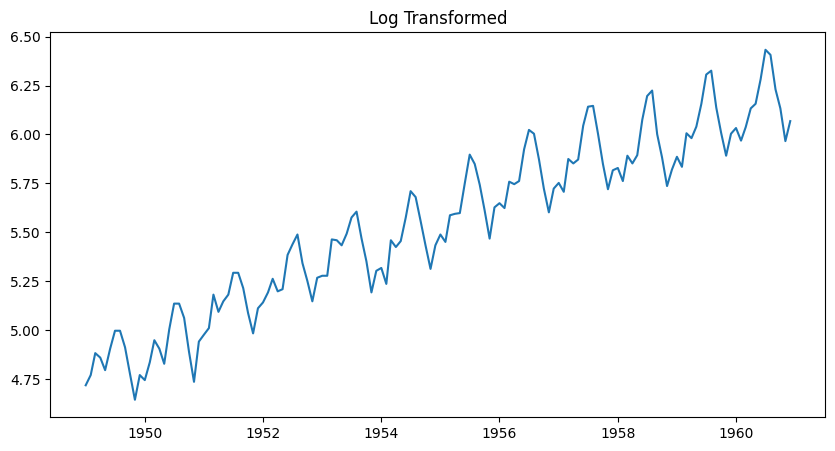

In [25]:
plt.figure(figsize=(10,5))
plt.plot(df_log)
plt.title("Log Transformed")
plt.show()

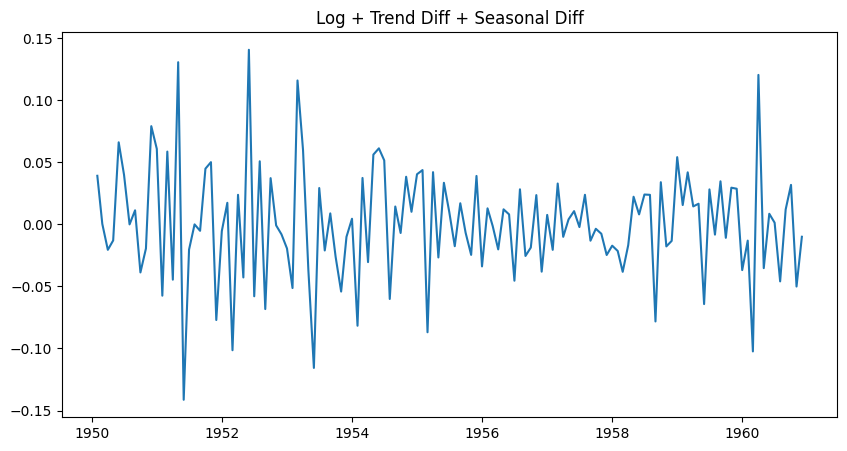

In [33]:
df_log_diff = df_log.diff().dropna()
df_log_diff_seasonal = df_log_diff.diff(12).dropna()

plt.figure(figsize=(10,5))
plt.plot(df_log_diff_seasonal)
plt.title("Log + Trend Diff + Seasonal Diff")
plt.show()

In [36]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_log_diff_seasonal['Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.4433249418311185
p-value: 0.00024859123113840924


<Figure size 1500x400 with 0 Axes>

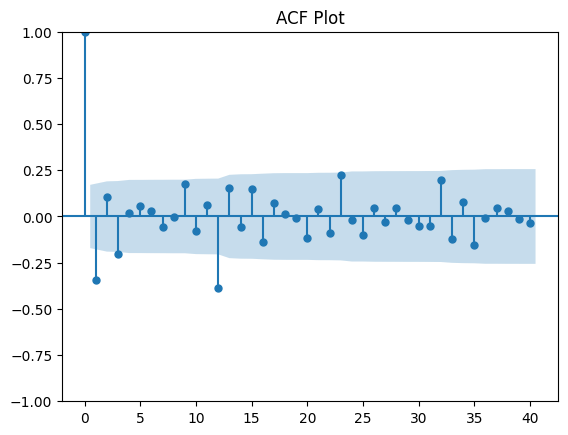

In [39]:
from statsmodels.graphics.tsaplots import plot_acf
plt.figure(figsize=(15,4))
plot_acf(df_log_diff_seasonal["Passengers"],lags=40)
plt.title("ACF Plot")
plt.show()

<Figure size 1500x400 with 0 Axes>

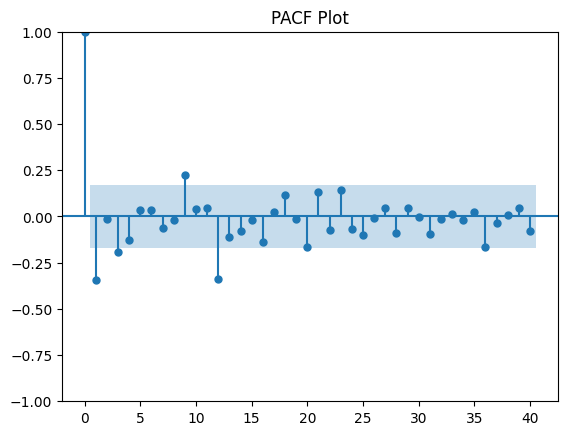

In [43]:
from statsmodels.graphics.tsaplots import plot_pacf
plt.figure(figsize=(15,4))
plot_pacf(df_log_diff_seasonal["Passengers"],lags=40)
plt.title("PACF Plot")
plt.show()

In [44]:
# Splitting the data 
train=df_log[:'1958-12-01']
test=df_log['1959-01-01':]
print(train.shape)
print(test.shape)

(120, 1)
(24, 1)


In [47]:
from statsmodels.tsa.arima.model import ARIMA
model_arima=ARIMA(train,order=(1,1,1))
results_arima=model_arima.fit()
print(results_arima.summary())

C:\Users\Kishore\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kishore\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kishore\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 103.840
Date:                Wed, 25 Feb 2026   AIC                           -201.680
Time:                        15:58:24   BIC                           -193.342
Sample:                    01-01-1949   HQIC                          -198.294
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5762      0.191     -3.015      0.003      -0.951      -0.202
ma.L1          0.8348      0.117      7.133      0.000       0.605       1.064
sigma2         0.0102      0.002      5.556      0.0

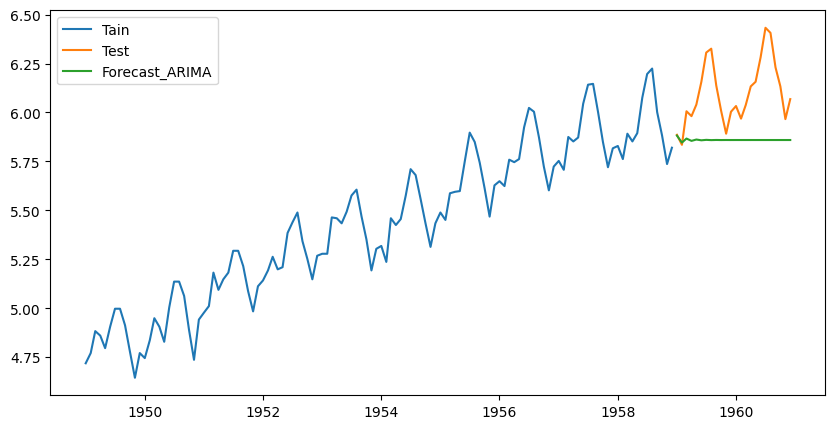

In [58]:
forecast_arima=results_arima.forecast(steps=len(test))
plt.figure(figsize=(10,5))
plt.plot(train,label="Tain")
plt.plot(test,label="Test")
plt.plot(forecast_arima,label="Forecast_ARIMA")
plt.legend()
plt.show()

In [50]:
from sklearn.metrics import mean_squared_error
rmse_arima=np.sqrt(mean_squared_error(test,forecast_arima))
print("ARIMA RMSE:",rmse_arima)

ARIMA RMSE: 0.2893309541528468


In [56]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_sarima=SARIMAX(train,order=(1,1,1),seasonal_order=(1,1,1,12))
results_sarima=model_sarima.fit()
print(results_sarima.summary())

C:\Users\Kishore\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Kishore\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 197.445
Date:                            Wed, 25 Feb 2026   AIC                           -384.891
Time:                                    16:19:58   BIC                           -371.527
Sample:                                01-01-1949   HQIC                          -379.473
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2176      0.307     -0.709      0.478      -0.819       0.384
ma.L1         -0.1110      0.331   

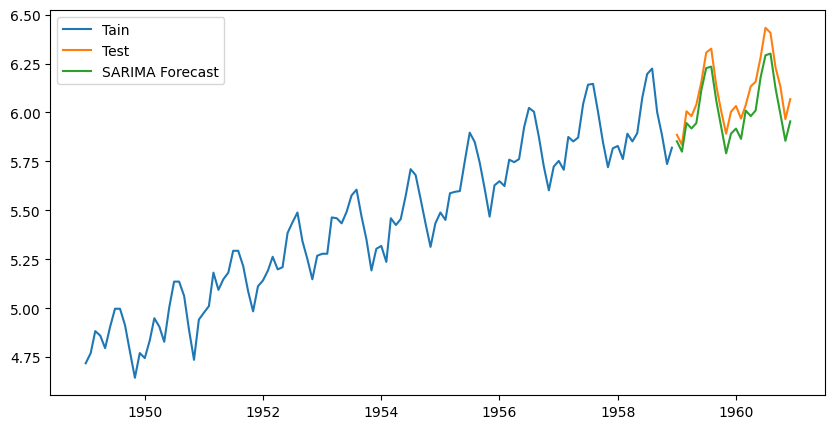

In [57]:
forecast_sarima=results_sarima.forecast(steps=len(test))
plt.figure(figsize=(10,5))
plt.plot(train,label="Tain")
plt.plot(test,label="Test")
plt.plot(forecast_sarima,label="SARIMA Forecast")
plt.legend()
plt.show()

In [59]:
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 0.09948597877835672


In [60]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 6.0 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.1 MB 6.0 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.1 MB 5.8 MB/s eta 0:00:02
   ------------------ --------------------- 5.5/12.1 MB 5.8 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.1 MB 5.7 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 5.7 MB/s eta 0:00:01
   ---------------------------------- ----- 10.5/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.8 MB/s eta 0:00:01



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
